NSE session: 200
Index API: 200
NIFTY 50 Spot: 22421.95
Contract API: 200

Selected Expiries:
06-Oct-2026 | 4 days
13-Oct-2026 | 11 days
19-Oct-2026 | 17 days
27-Oct-2026 | 25 days
03-Nov-2026 | 32 days
23-Nov-2026 | 52 days
29-Dec-2026 | 88 days
30-Mar-2027 | 179 days

Processing 06-Oct-2026...

Processing 13-Oct-2026...

Processing 19-Oct-2026...

Processing 27-Oct-2026...

Processing 03-Nov-2026...

Processing 23-Nov-2026...

Processing 29-Dec-2026...

Processing 30-Mar-2027...

========== TERM STRUCTURE DATA ==========


,expiry,days_to_expiry,strike,option_type,iv_pct,ltp,volume,oi
0,06-Oct-2026,4,22400.0,CE,12.33,156.95,1666564.0,54828.0
1,06-Oct-2026,4,22400.0,PE,12.26,103.60,2721530.0,65164.0
2,13-Oct-2026,11,22400.0,CE,13.16,264.15,47400.0,7772.0
3,13-Oct-2026,11,22400.0,PE,14.13,184.10,87402.0,18269.0
4,19-Oct-2026,17,22400.0,CE,13.27,334.20,1874.0,310.0
5,19-Oct-2026,17,22400.0,PE,14.55,226.80,3027.0,397.0
6,27-Oct-2026,25,22400.0,CE,12.67,400.40,36673.0,11311.0
7,27-Oct-2026,25,22400.0,PE,14.86,270.25,51311.0,15034.0
8,03-Nov-2026,32,22400.0,CE,12.03,446.00,145.0,77.0
9,03-Nov-2026,32,22400.0,PE,15.04,300.40,412.0,108.0


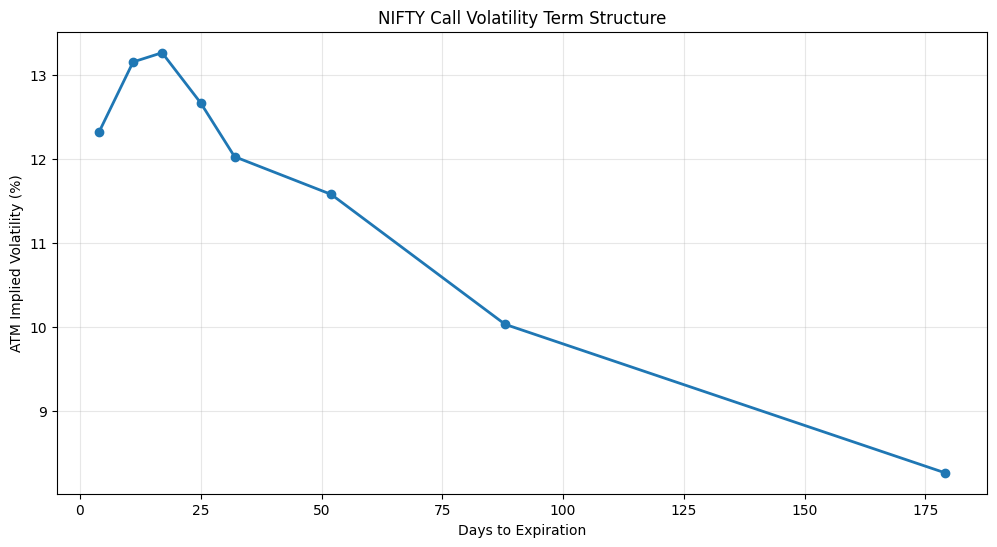

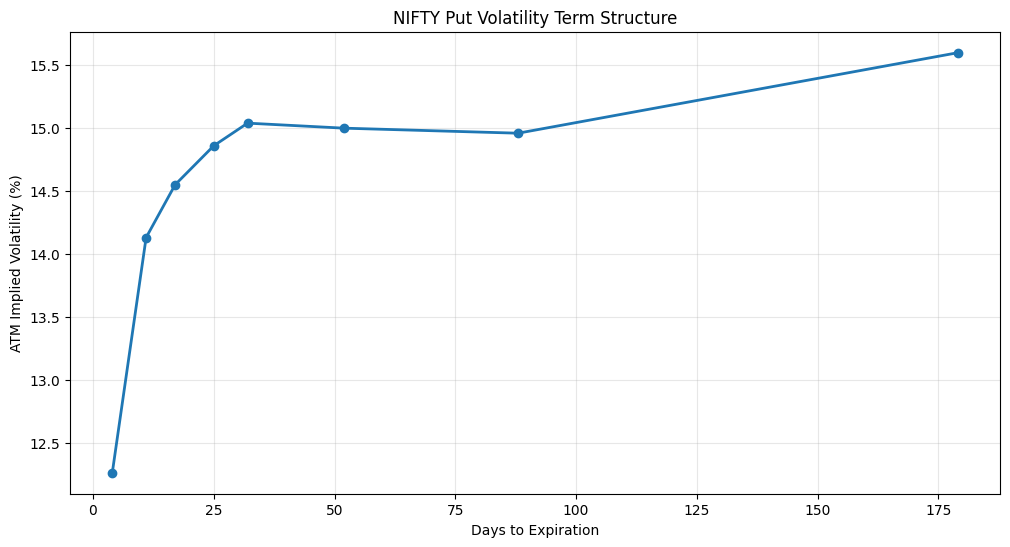

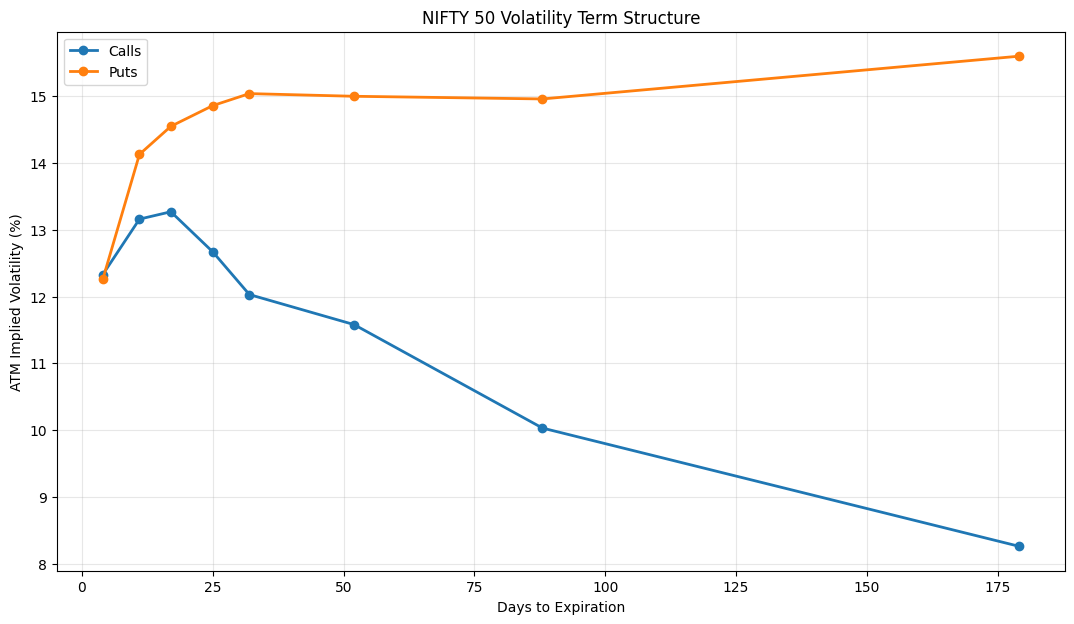


Call Term-Structure Slope: -0.0233 IV points/day

========== SUMMARY ==========


,Maturity,Days,Call_IV,Put_IV
0,Shortest,4,12.33,12.26
1,Longest,179,8.26,15.60



Files saved:
NIFTY_Volatility_Term_Structure.csv
NIFTY_Term_Structure_Summary.csv

PROJECT 2 COMPLETE
NIFTY Spot: 22421.95
✓ Multiple Expiries
✓ ATM Implied Volatility
✓ Call Term Structure
✓ Put Term Structure
✓ Term Structure Slope


In [4]:
# ============================================================
# PROJECT 2: NIFTY VOLATILITY TERM STRUCTURE
# ============================================================

!pip -q install curl_cffi pandas numpy matplotlib

from curl_cffi import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import warnings

warnings.filterwarnings("ignore")


# ============================================================
# 1. NSE SESSION
# ============================================================

session = requests.Session(
    impersonate="chrome"
)

headers = {
    "Accept": "application/json, text/plain, */*",
    "Accept-Language": "en-US,en;q=0.9",
    "Referer": "https://www.nseindia.com/option-chain",
}

session.headers.update(headers)

home = session.get(
    "https://www.nseindia.com/option-chain",
    timeout=20
)

print("NSE session:", home.status_code)


# ============================================================
# 2. GET NIFTY SPOT FROM NSE INDEX API
# ============================================================

index_url = (
    "https://www.nseindia.com/api/allIndices"
)

index_response = session.get(
    index_url,
    timeout=20
)

print(
    "Index API:",
    index_response.status_code
)

if index_response.status_code != 200:

    raise Exception(
        f"NSE index API failed: "
        f"{index_response.status_code}"
    )

index_data = index_response.json()


# ============================================================
# 3. FIND NIFTY 50
# ============================================================

spot = None

for item in index_data.get("data", []):

    index_name = str(
        item.get("index", "")
    ).upper()

    if index_name == "NIFTY 50":

        spot = float(
            item["last"]
        )

        break


if spot is None:

    raise Exception(
        "NIFTY 50 spot price not found."
    )


print(
    f"NIFTY 50 Spot: {spot:.2f}"
)


# ============================================================
# 4. GET NIFTY EXPIRY INFORMATION
# ============================================================

contract_url = (
    "https://www.nseindia.com/api/"
    "option-chain-contract-info"
)

contract_response = session.get(
    contract_url,
    params={"symbol": "NIFTY"},
    timeout=20
)

print(
    "Contract API:",
    contract_response.status_code
)

if contract_response.status_code != 200:

    raise Exception(
        f"NSE contract API failed: "
        f"{contract_response.status_code}"
    )

contract_data = contract_response.json()


# ============================================================
# 5. EXTRACT EXPIRIES
# ============================================================

def find_expiry_strings(obj):

    result = []

    if isinstance(obj, dict):

        for key, value in obj.items():

            if "expiry" in str(key).lower():

                if isinstance(value, list):

                    for x in value:

                        if isinstance(x, str):
                            result.append(x)

            result.extend(
                find_expiry_strings(value)
            )

    elif isinstance(obj, list):

        for item in obj:

            result.extend(
                find_expiry_strings(item)
            )

    return result


expiry_strings = list(
    dict.fromkeys(
        find_expiry_strings(
            contract_data
        )
    )
)


# ============================================================
# 6. PARSE EXPIRIES
# ============================================================

def parse_expiry(x):

    formats = [
        "%d-%b-%Y",
        "%d-%B-%Y",
        "%d/%b/%Y",
        "%d/%B/%Y",
        "%Y-%m-%d",
        "%Y/%m/%d"
    ]

    for fmt in formats:

        try:

            return datetime.strptime(
                x,
                fmt
            )

        except:

            pass

    return None


today = datetime.now()

future_expiries = []

for expiry in expiry_strings:

    dt = parse_expiry(
        expiry
    )

    if dt is not None:

        if dt.date() >= today.date():

            future_expiries.append(
                (dt, expiry)
            )


future_expiries = sorted(
    future_expiries,
    key=lambda x: x[0]
)


if len(future_expiries) < 3:

    raise Exception(
        "Less than 3 future expiries found."
    )


# Use first 8 expiries
selected_expiries = (
    future_expiries[:8]
)


print(
    "\nSelected Expiries:"
)

for dt, expiry in selected_expiries:

    print(
        expiry,
        "|",
        (dt.date() - today.date()).days,
        "days"
    )


# ============================================================
# 7. OPTION-CHAIN FUNCTION
# ============================================================

def get_option_chain(expiry):

    url = (
        "https://www.nseindia.com/api/"
        "option-chain-v3"
    )

    params = {
        "type": "Indices",
        "symbol": "NIFTY",
        "expiry": expiry
    }

    response = session.get(
        url,
        params=params,
        timeout=20
    )

    if response.status_code != 200:

        print(
            f"Failed {expiry}: "
            f"{response.status_code}"
        )

        return None

    return response.json()


# ============================================================
# 8. EXTRACT OPTION RECORDS
# ============================================================

def extract_records(obj):

    output = []

    if isinstance(obj, dict):

        strike = None

        for key in [
            "strikePrice",
            "strike_price",
            "strike"
        ]:

            if key in obj:

                try:

                    strike = float(
                        obj[key]
                    )

                except:

                    pass


        ce = obj.get("CE")

        pe = obj.get("PE")


        if strike is not None:

            if isinstance(ce, dict):

                output.append({
                    "strike":
                        strike,

                    "option_type":
                        "CE",

                    "option":
                        ce
                })


            if isinstance(pe, dict):

                output.append({
                    "strike":
                        strike,

                    "option_type":
                        "PE",

                    "option":
                        pe
                })


        for value in obj.values():

            output.extend(
                extract_records(
                    value
                )
            )


    elif isinstance(obj, list):

        for item in obj:

            output.extend(
                extract_records(
                    item
                )
            )


    return output


# ============================================================
# 9. BUILD TERM STRUCTURE
# ============================================================

results = []


for expiry_dt, expiry in selected_expiries:

    print(
        f"\nProcessing {expiry}..."
    )

    chain = get_option_chain(
        expiry
    )

    if chain is None:
        continue


    records = extract_records(
        chain
    )


    if not records:

        print(
            "No option records."
        )

        continue


    # --------------------------------------------------------
    # Remove duplicate contracts
    # --------------------------------------------------------

    unique = {}

    for row in records:

        option = row["option"]

        key = (
            row["strike"],
            row["option_type"],
            option.get(
                "expiryDate",
                expiry
            )
        )

        unique[key] = row


    records = list(
        unique.values()
    )


    # --------------------------------------------------------
    # Find ATM strike
    # --------------------------------------------------------

    strikes = [
        x["strike"]
        for x in records
    ]

    atm_strike = min(
        strikes,
        key=lambda x:
        abs(x - spot)
    )


    # --------------------------------------------------------
    # Days to expiry
    # --------------------------------------------------------

    days = max(
        (
            expiry_dt.date()
            - today.date()
        ).days,
        0
    )


    # --------------------------------------------------------
    # Find ATM CALL and PUT
    # --------------------------------------------------------

    for option_type in [
        "CE",
        "PE"
    ]:

        candidates = [
            x
            for x in records
            if (
                x["option_type"]
                == option_type
                and
                x["strike"]
                == atm_strike
            )
        ]


        if not candidates:
            continue


        option = candidates[0][
            "option"
        ]


        # NSE published IV
        iv = option.get(
            "impliedVolatility"
        )


        ltp = option.get(
            "lastPrice"
        )


        volume = option.get(
            "totalTradedVolume"
        )


        oi = option.get(
            "openInterest"
        )


        try:

            iv = float(iv)

        except:

            iv = np.nan


        try:

            ltp = float(ltp)

        except:

            ltp = np.nan


        try:

            volume = float(volume)

        except:

            volume = np.nan


        try:

            oi = float(oi)

        except:

            oi = np.nan


        if (
            pd.isna(iv)
            or iv <= 0
        ):

            continue


        results.append({

            "expiry":
                expiry,

            "days_to_expiry":
                days,

            "strike":
                atm_strike,

            "option_type":
                option_type,

            "iv_pct":
                iv,

            "ltp":
                ltp,

            "volume":
                volume,

            "oi":
                oi
        })


# ============================================================
# 10. DATAFRAME
# ============================================================

term_structure = pd.DataFrame(
    results
)


if term_structure.empty:

    raise Exception(
        "No valid term-structure data."
    )


term_structure = (
    term_structure
    .sort_values(
        "days_to_expiry"
    )
)


print(
    "\n========== TERM STRUCTURE DATA =========="
)

display(
    term_structure.round(2)
)


# ============================================================
# 11. CALL TERM STRUCTURE
# ============================================================

calls = term_structure[
    term_structure["option_type"]
    == "CE"
]


plt.figure(
    figsize=(12, 6)
)

plt.plot(
    calls["days_to_expiry"],
    calls["iv_pct"],
    marker="o",
    linewidth=2
)

plt.xlabel(
    "Days to Expiration"
)

plt.ylabel(
    "ATM Implied Volatility (%)"
)

plt.title(
    "NIFTY Call Volatility Term Structure"
)

plt.grid(
    alpha=0.3
)

plt.show()


# ============================================================
# 12. PUT TERM STRUCTURE
# ============================================================

puts = term_structure[
    term_structure["option_type"]
    == "PE"
]


plt.figure(
    figsize=(12, 6)
)

plt.plot(
    puts["days_to_expiry"],
    puts["iv_pct"],
    marker="o",
    linewidth=2
)

plt.xlabel(
    "Days to Expiration"
)

plt.ylabel(
    "ATM Implied Volatility (%)"
)

plt.title(
    "NIFTY Put Volatility Term Structure"
)

plt.grid(
    alpha=0.3
)

plt.show()


# ============================================================
# 13. COMBINED TERM STRUCTURE
# ============================================================

plt.figure(
    figsize=(13, 7)
)

plt.plot(
    calls["days_to_expiry"],
    calls["iv_pct"],
    marker="o",
    linewidth=2,
    label="Calls"
)

plt.plot(
    puts["days_to_expiry"],
    puts["iv_pct"],
    marker="o",
    linewidth=2,
    label="Puts"
)

plt.xlabel(
    "Days to Expiration"
)

plt.ylabel(
    "ATM Implied Volatility (%)"
)

plt.title(
    "NIFTY 50 Volatility Term Structure"
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.show()


# ============================================================
# 14. TERM STRUCTURE SLOPE
# ============================================================

if len(calls) >= 2:

    short_iv = (
        calls.iloc[0]["iv_pct"]
    )

    long_iv = (
        calls.iloc[-1]["iv_pct"]
    )

    short_days = (
        calls.iloc[0]["days_to_expiry"]
    )

    long_days = (
        calls.iloc[-1]["days_to_expiry"]
    )

    slope = (
        (long_iv - short_iv)
        /
        (long_days - short_days)
    )

    print(
        "\nCall Term-Structure Slope:",
        round(slope, 4),
        "IV points/day"
    )


# ============================================================
# 15. TERM STRUCTURE SUMMARY
# ============================================================

summary = pd.DataFrame({

    "Maturity": [
        "Shortest",
        "Longest"
    ],

    "Days": [
        calls.iloc[0]["days_to_expiry"],
        calls.iloc[-1]["days_to_expiry"]
    ],

    "Call_IV": [
        calls.iloc[0]["iv_pct"],
        calls.iloc[-1]["iv_pct"]
    ],

    "Put_IV": [
        puts.iloc[0]["iv_pct"],
        puts.iloc[-1]["iv_pct"]
    ]
})


print(
    "\n========== SUMMARY =========="
)

display(
    summary.round(2)
)


# ============================================================
# 16. EXPORT
# ============================================================

term_structure.to_csv(
    "NIFTY_Volatility_Term_Structure.csv",
    index=False
)

summary.to_csv(
    "NIFTY_Term_Structure_Summary.csv",
    index=False
)


print(
    "\nFiles saved:"
)

print(
    "NIFTY_Volatility_Term_Structure.csv"
)

print(
    "NIFTY_Term_Structure_Summary.csv"
)


# ============================================================
# FINAL
# ============================================================

print(
    "\n=============================================="
)

print(
    "PROJECT 2 COMPLETE"
)

print(
    "=============================================="
)

print(
    f"NIFTY Spot: {spot:.2f}"
)

print(
    "✓ Multiple Expiries"
)

print(
    "✓ ATM Implied Volatility"
)

print(
    "✓ Call Term Structure"
)

print(
    "✓ Put Term Structure"
)

print(
    "✓ Term Structure Slope"
)

print(
    "=============================================="
)